# Results for Syntethic generators

### Imports

In [1]:
import time
import logging
from itertools import tee

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from river import datasets
from river import preprocessing
from river import base, metrics, stats, preprocessing, datasets
from river.drift import ADWIN, NoDrift

In [3]:
SEED = 42

In [5]:
from evaluation import evaluate_model

help(evaluate_model)

Help on function evaluate_model in module evaluation:

evaluate_model(model, stream, name, print_interval=10000, metric_class=<class 'river.metrics.mae.MAE'>, track_model_count=False, verbose=True)
    Evaluate a River/River-extended regressor model on a data stream.
    
    Args:
        model: River-compatible regressor with `learn_one`, `predict_one`, and optionally `__len__` and `n_drifts_detected`.
        stream: Iterable yielding (x, y) pairs.
        name (str): Display name of the model.
        print_interval (int): Instance step interval to log progress.
        metric_class: River metric class, e.g., metrics.MAE.
        track_model_count (bool): Track number of models in the ensemble.
        verbose (bool): If True, logs progress info using the logging module.
    
    Returns:
        dict: {
            "name": str,
            "metric": river.Metric,
            "mae_history": list,
            "model_count_history": list or None,
            "duration": float (second


Evaluating ARFStandard on Friedman...

Evaluating DWARF on Friedman...

Evaluating ARFER on Friedman...
[SmartARF Step 1] First learn_one. Effective n_models=10, max_models=20, min_ensemble_size=5
[SmartARF Step 1] Start learn_one. Current ensemble size: 10
[SmartARF Step 1] End learn_one. Final ensemble size: 10
[SmartARF Step 2] Start learn_one. Current ensemble size: 10
[SmartARF Step 2] End learn_one. Final ensemble size: 10
[SmartARF Step 3] Start learn_one. Current ensemble size: 10
[SmartARF Step 3] End learn_one. Final ensemble size: 10
[SmartARF Step 4] Start learn_one. Current ensemble size: 10
[SmartARF Step 4] End learn_one. Final ensemble size: 10
[SmartARF Step 5] Start learn_one. Current ensemble size: 10
[SmartARF Step 5] End learn_one. Final ensemble size: 10
[SmartARF Step 6] Start learn_one. Current ensemble size: 10
[SmartARF Step 6] End learn_one. Final ensemble size: 10
[SmartARF Step 7] Start learn_one. Current ensemble size: 10
[SmartARF Step 7] End learn_one. 

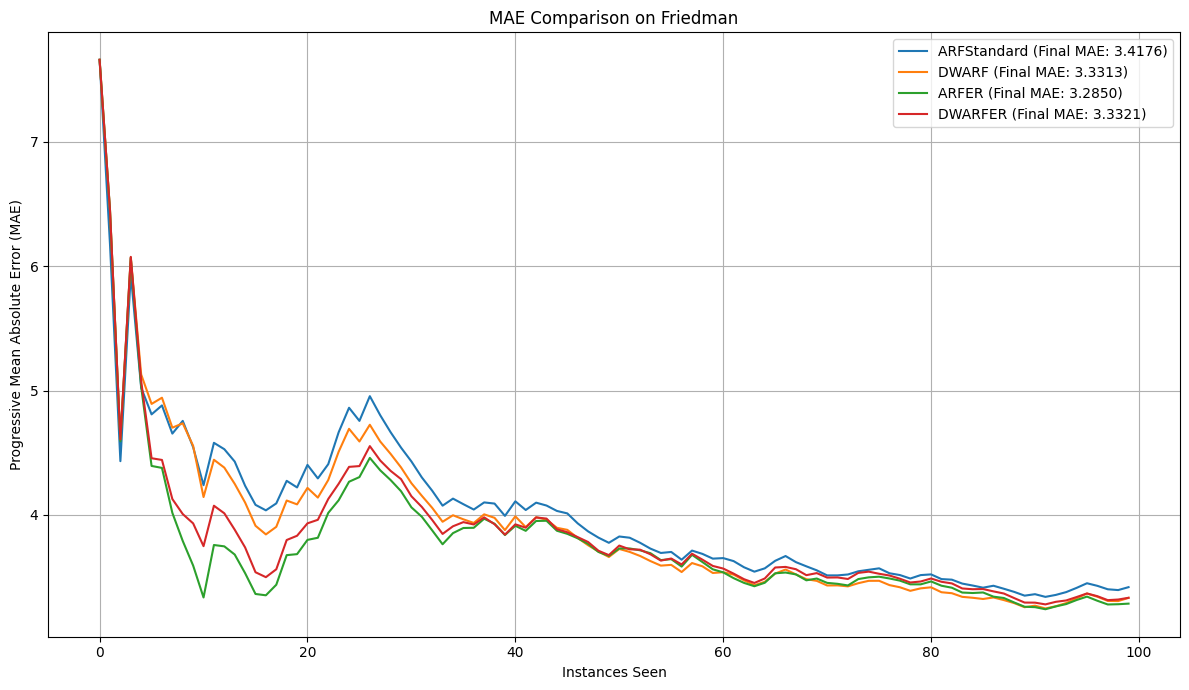


--- Plotting Model Counts ---


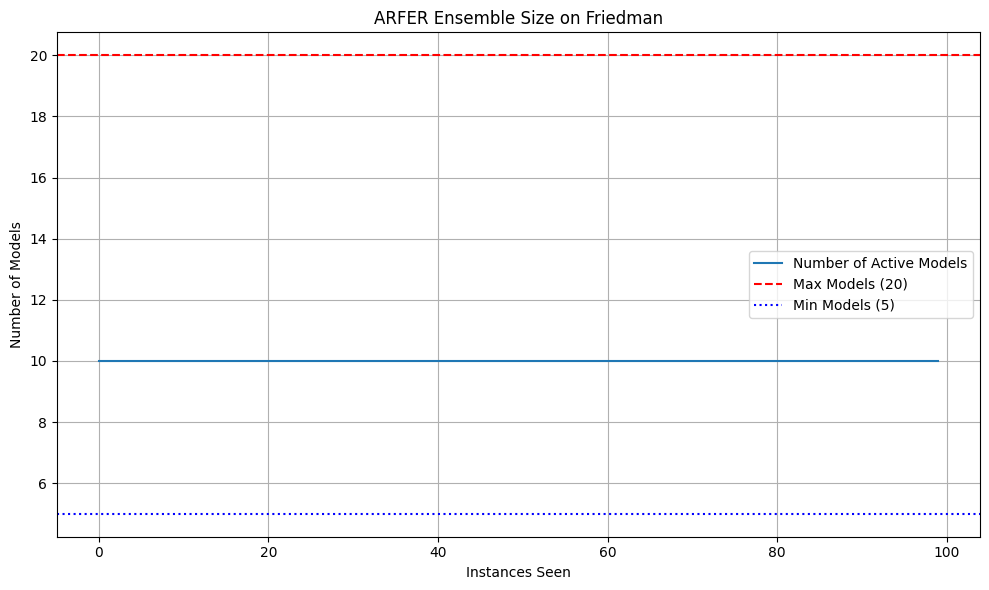

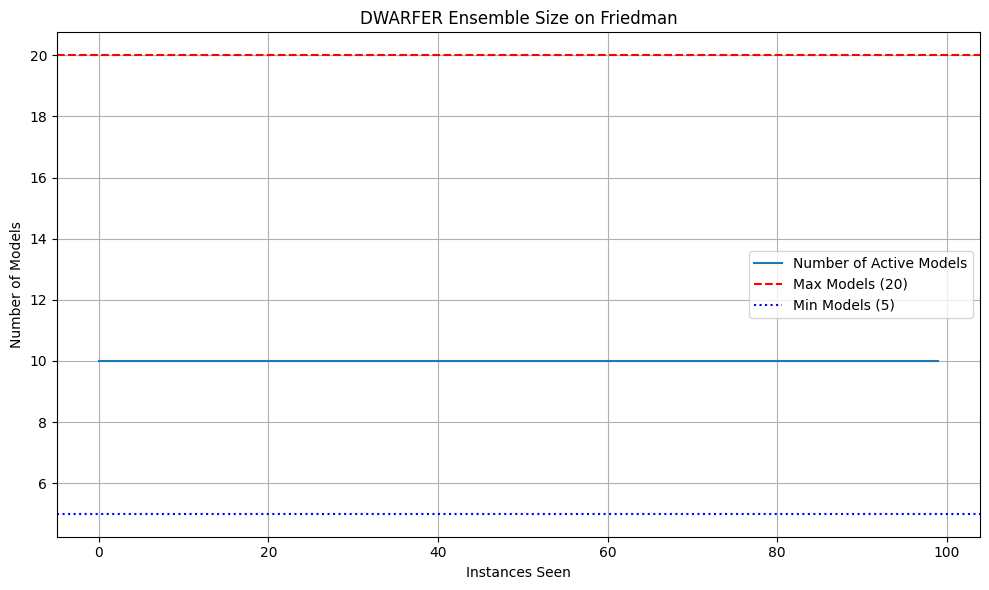


Evaluating ARFStandard on FriedmanDrift...

Evaluating DWARF on FriedmanDrift...

Evaluating ARFER on FriedmanDrift...
[SmartARF Step 1] First learn_one. Effective n_models=10, max_models=20, min_ensemble_size=5
[SmartARF Step 1] Start learn_one. Current ensemble size: 10
[SmartARF Step 1] End learn_one. Final ensemble size: 10
[SmartARF Step 2] Start learn_one. Current ensemble size: 10
[SmartARF Step 2] End learn_one. Final ensemble size: 10
[SmartARF Step 3] Start learn_one. Current ensemble size: 10
[SmartARF Step 3] End learn_one. Final ensemble size: 10
[SmartARF Step 4] Start learn_one. Current ensemble size: 10
[SmartARF Step 4] End learn_one. Final ensemble size: 10
[SmartARF Step 5] Start learn_one. Current ensemble size: 10
[SmartARF Step 5] End learn_one. Final ensemble size: 10
[SmartARF Step 6] Start learn_one. Current ensemble size: 10
[SmartARF Step 6] End learn_one. Final ensemble size: 10
[SmartARF Step 7] Start learn_one. Current ensemble size: 10
[SmartARF Step 7] 

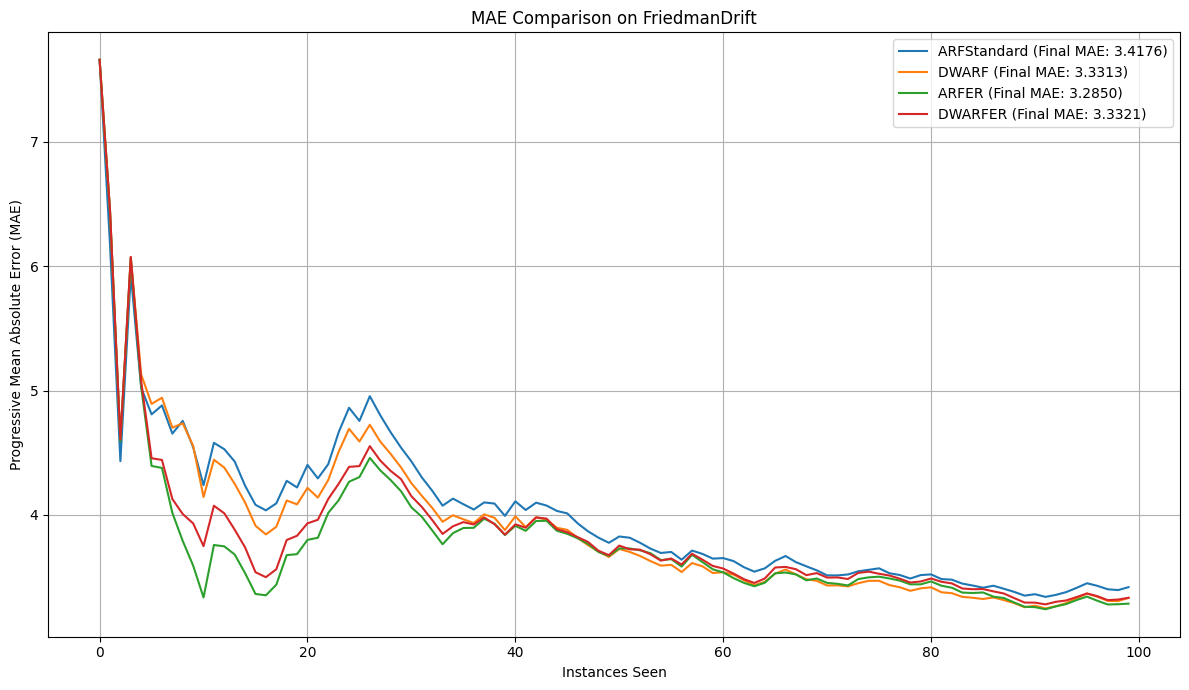


--- Plotting Model Counts ---


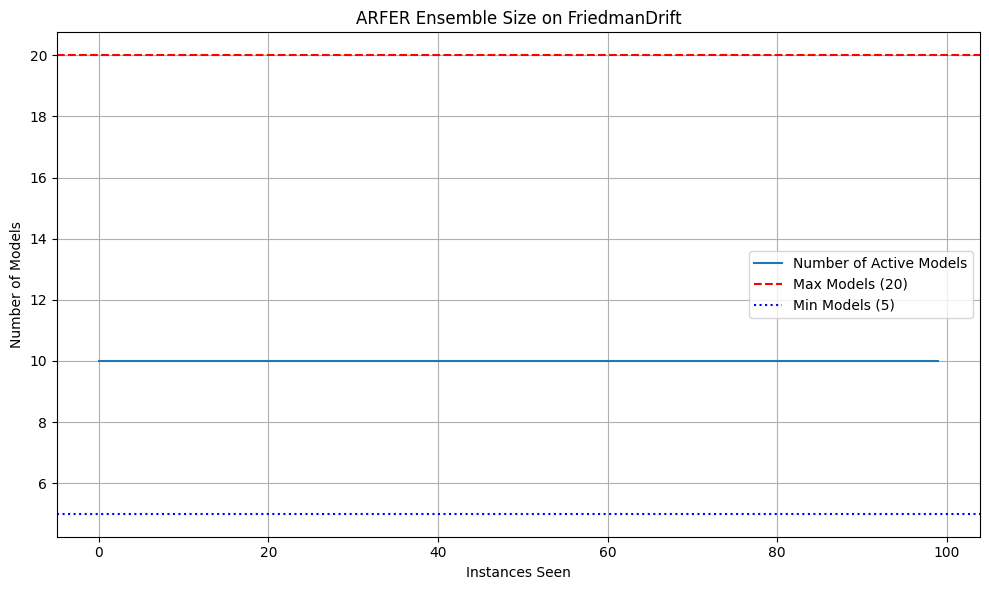

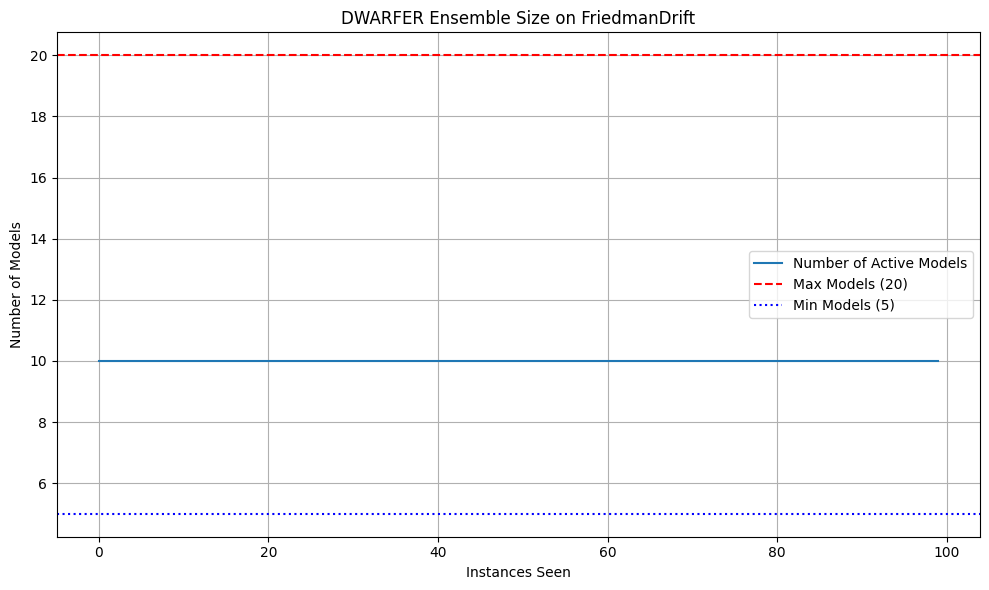


Evaluating ARFStandard on Planes2D...

Evaluating DWARF on Planes2D...

Evaluating ARFER on Planes2D...
[SmartARF Step 1] First learn_one. Effective n_models=10, max_models=20, min_ensemble_size=5
[SmartARF Step 1] Start learn_one. Current ensemble size: 10
[SmartARF Step 1] End learn_one. Final ensemble size: 10
[SmartARF Step 2] Start learn_one. Current ensemble size: 10
[SmartARF Step 2] End learn_one. Final ensemble size: 10
[SmartARF Step 3] Start learn_one. Current ensemble size: 10
[SmartARF Step 3] End learn_one. Final ensemble size: 10
[SmartARF Step 4] Start learn_one. Current ensemble size: 10
[SmartARF Step 4] End learn_one. Final ensemble size: 10
[SmartARF Step 5] Start learn_one. Current ensemble size: 10
[SmartARF Step 5] End learn_one. Final ensemble size: 10
[SmartARF Step 6] Start learn_one. Current ensemble size: 10
[SmartARF Step 6] End learn_one. Final ensemble size: 10
[SmartARF Step 7] Start learn_one. Current ensemble size: 10
[SmartARF Step 7] End learn_one. 

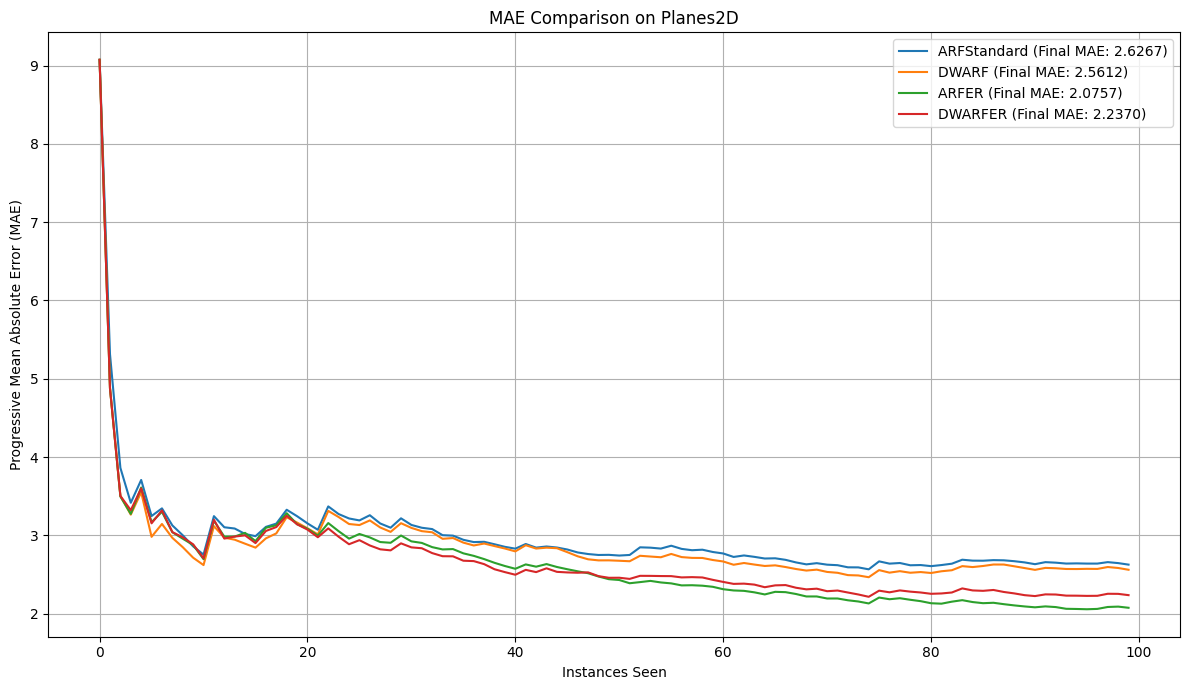


--- Plotting Model Counts ---


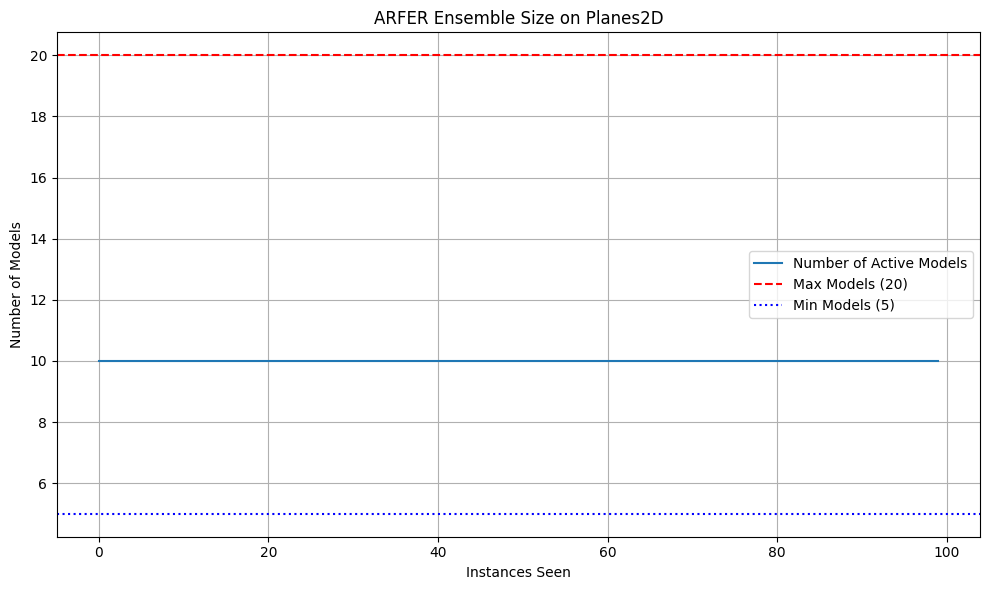

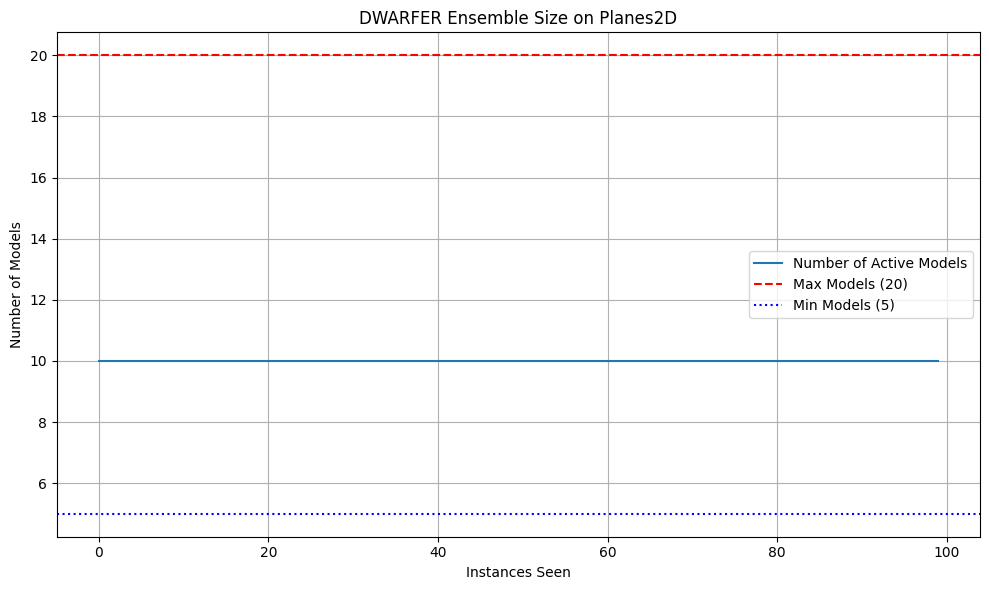


✅ All results saved to regression_results_final.csv


In [ ]:
import os
import csv
from itertools import tee
import matplotlib.pyplot as plt
from models import SmartARFRegressor, ARFRegressorDynamicWeights, SmartARFDynamicWeightsRegressor
from river import metrics, preprocessing, forest
from river.drift import ADWIN
from river.datasets import synth
from river.forest import ARFRegressor
from river import metrics

def make_standard_arf(n_models=10,
                      seed=42,
                      lambda_value=6,
                      grace_period=50,
                      leaf_prediction="adaptive",
                      metric=metrics.MAE(),
                      drift_detector=ADWIN(delta=0.001),
                      warning_detector=ADWIN(delta=0.01)):
    return ARFRegressor(
        n_models=n_models,
        seed=seed,
        lambda_value=lambda_value,
        grace_period=grace_period,
        leaf_prediction=leaf_prediction,
        metric=metric,
        drift_detector=drift_detector,
        warning_detector=warning_detector,
    )


def make_arf_dw(n_models=10,
                seed=42,
                lambda_value=6,
                grace_period=50,
                leaf_prediction="adaptive",
                metric=metrics.MAE(),
                drift_detector=ADWIN(delta=0.001),
                warning_detector=ADWIN(delta=0.01),
                error_mode="std",
                error_threshold_factor=1.0):
    return ARFRegressorDynamicWeights(
        n_models=n_models,
        seed=seed,
        lambda_value=lambda_value,
        grace_period=grace_period,
        leaf_prediction=leaf_prediction,
        metric=metric,
        drift_detector=drift_detector,
        warning_detector=warning_detector,
        error_mode=error_mode,
        error_threshold_factor=error_threshold_factor,
    )


def make_smart_arf(n_models=10,
                   max_models=20,
                   min_ensemble_size=5,
                   seed=42,
                   lambda_value=6,
                   grace_period=6,
                   leaf_prediction="adaptive",
                   metric=metrics.MAE(),
                   drift_detector=ADWIN(delta=0.01),
                   warning_detector=ADWIN(delta=0.1),
                   verbose=True):

    return SmartARFRegressor(
        n_models=n_models,
        max_models=max_models,
        min_ensemble_size=min_ensemble_size,
        seed=seed,
        lambda_value=lambda_value,
        grace_period=grace_period,
        leaf_prediction=leaf_prediction,
        metric=metric,
        drift_detector=drift_detector,
        warning_detector=warning_detector,
        verbose_logging=verbose,
    )


def make_smart_arf_dw(n_models=10,
                      max_models=20,
                      min_ensemble_size=5,
                      seed=42,
                      lambda_value=6,
                      grace_period=6,
                      leaf_prediction="adaptive",
                      metric=metrics.MAE(),
                      drift_detector=ADWIN(delta=0.01),
                      warning_detector=ADWIN(delta=0.1),
                      regression_pruning_error_threshold=0.1,
                      accuracy_drop_threshold=0.5,
                      monitor_window=100,
                      error_mode="std",
                      error_threshold_factor=1.0,
                      verbose=True):
    model = SmartARFDynamicWeightsRegressor(
        n_models=n_models,
        max_models=max_models,
        min_ensemble_size=min_ensemble_size,
        seed=seed,
        lambda_value=lambda_value,
        grace_period=grace_period,
        leaf_prediction=leaf_prediction,
        metric=metric,
        drift_detector=drift_detector,
        warning_detector=warning_detector,
        regression_pruning_error_threshold=regression_pruning_error_threshold,
        accuracy_drop_threshold=accuracy_drop_threshold,
        monitor_window=monitor_window,
        error_mode=error_mode,
        error_threshold_factor=error_threshold_factor,
    )
    if hasattr(model, 'verbose_logging'):
        model.verbose_logging = verbose
    return model


import os
import csv
from itertools import tee
import matplotlib.pyplot as plt

# --- River and Model Imports ---
from models import SmartARFRegressor, ARFRegressorDynamicWeights, SmartARFDynamicWeightsRegressor
from river import metrics, preprocessing, forest
from river.drift import ADWIN
from river.datasets import synth

# --- CSV Setup ---
CSV_PATH = "regression_results_final.csv"
FIELDNAMES = ["dataset", "model_name", "MAE", "RMSE", "R2"]
N_SAMPLES = 100000

if not os.path.exists(CSV_PATH):
    with open(CSV_PATH, mode="w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=FIELDNAMES)
        writer.writeheader()

if not os.path.exists(CSV_PATH):
    with open(CSV_PATH, mode="w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=FIELDNAMES)
        writer.writeheader()

# --------------------------
# Evaluation Function
# --------------------------
def evaluate_all_models(dataset_name, stream):
    stream_arf, stream_dwarf, stream_arfer, stream_dwarfer = tee(stream, 4)
    model_arf = make_standard_arf()
    model_dwarf = make_arf_dw()
    model_arfer = make_smart_arf()
    model_dwarfer = make_smart_arf_dw()
    
    all_results = {}
    def run_evaluation_loop(model_name, model, data_stream):
        print(f"\nEvaluating {model_name} on {dataset_name}...")
        metrics_dict = {"MAE": metrics.MAE(), "RMSE": metrics.RMSE(), "R2": metrics.R2()}
        mae_history = []
        for i, (x, y) in enumerate(data_stream):
            pred = model.predict_one(x)
            if pred is not None:
                for m in metrics_dict.values():
                    m.update(y, pred)
            model.learn_one(x, y)
            mae_history.append(metrics_dict["MAE"].get())
            if (i + 1) % 10000 == 0:
                 print(f"  [{model_name}] Processed {i+1} instances. MAE: {metrics_dict['MAE'].get():.4f}")
        all_results[model_name] = {"metrics": metrics_dict, "mae_history": mae_history}

    # Run the evaluation for all four models
    run_evaluation_loop("ARFStandard", model_arf, stream_arf)
    run_evaluation_loop("DWARF", model_dwarf, stream_dwarf)
    run_evaluation_loop("ARFER", model_arfer, stream_arfer)
    run_evaluation_loop("DWARFER", model_dwarfer, stream_dwarfer)

    # --- Output, CSV, and Plotting ---
    # (This section is the same as before)
    print(f"\n📊 [{dataset_name.upper()}] Final Results")
    for name, res in all_results.items():
        mae = res['metrics']['MAE'].get()
        r2 = res['metrics']['R2'].get()
        print(f"  {name:<12}: MAE={mae:.4f}, R2={r2:.4f}")

    with open(CSV_PATH, mode="a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=FIELDNAMES)
        for name, res in all_results.items():
            writer.writerow({
                "dataset": dataset_name, "model_name": name,
                **{k: f"{m.get():.4f}" for k, m in res["metrics"].items()}
            })

    plt.figure(figsize=(12, 7))
    for name, res in all_results.items():
        final_mae = res['metrics']['MAE'].get()
        label_text = f"{name} (Final MAE: {final_mae:.4f})"
        plt.plot(res["mae_history"], label=label_text)
    plt.title(f"MAE Comparison on {dataset_name}")
    plt.xlabel("Instances Seen")
    plt.ylabel("Progressive Mean Absolute Error (MAE)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print("\n--- Plotting Model Counts ---")
    # Plot for ARFER
    if hasattr(model_arfer, 'model_count_history') and model_arfer.model_count_history:
        plt.figure(figsize=(10, 6))
        plt.plot(model_arfer.model_count_history, label='Number of Active Models', drawstyle='steps-post')
        plt.title(f"ARFER Ensemble Size on {dataset_name}")
        plt.xlabel("Instances Seen")
        plt.ylabel("Number of Models")
        if hasattr(model_arfer, 'max_models'):
            plt.axhline(y=model_arfer.max_models, color='r', linestyle='--', label=f'Max Models ({model_arfer.max_models})')
        if hasattr(model_arfer, 'min_ensemble_size'):
             plt.axhline(y=model_arfer.min_ensemble_size, color='b', linestyle=':', label=f'Min Models ({model_arfer.min_ensemble_size})')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    
    # Plot for DWARFER
    if hasattr(model_dwarfer, 'model_count_history') and model_dwarfer.model_count_history:
        plt.figure(figsize=(10, 6))
        plt.plot(model_dwarfer.model_count_history, label='Number of Active Models', drawstyle='steps-post')
        plt.title(f"DWARFER Ensemble Size on {dataset_name}")
        plt.xlabel("Instances Seen")
        plt.ylabel("Number of Models")
        if hasattr(model_dwarfer, 'max_models'):
            plt.axhline(y=model_dwarfer.max_models, color='r', linestyle='--', label=f'Max Models ({model_dwarfer.max_models})')
        if hasattr(model_dwarfer, 'min_ensemble_size'):
             plt.axhline(y=model_dwarfer.min_ensemble_size, color='b', linestyle=':', label=f'Min Models ({model_dwarfer.min_ensemble_size})')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


# Dataset and Run Setup
# --------------------------
regression_datasets = [
    ("Friedman", synth.Friedman(seed=42).take(N_SAMPLES)),
    ("FriedmanDrift", synth.FriedmanDrift(seed=42).take(N_SAMPLES)),
    ("Planes2D", synth.Planes2D(seed=42).take(N_SAMPLES))
]

for name, stream in regression_datasets:
    evaluate_all_models(name, stream)

print(f"\n✅ All results saved to {CSV_PATH}")
